In [2]:
import pandas as pd
import numpy as np

NUM_COLS = [f'I{i}' for i in range(1, 14)]
CAT_COLS = [f'C{i}' for i in range(1, 27)]
ALL_COLS = ['label'] + NUM_COLS + CAT_COLS

df = pd.read_csv('kaggle-dataset/train.txt', sep='\t', header=None, names=ALL_COLS, nrows=100000)

print(df.shape)
print(df['label'].value_counts())
df.head()

(100000, 40)
label
0    77337
1    22663
Name: count, dtype: int64


,label,I1,I2,I3,I4,I5,I6,I7,I8,I9,...,C17,C18,C19,C20,C21,C22,C23,C24,C25,C26
0,0,1.0,1,5.0,0.0,1382.0,4.0,15.0,2.0,181.0,...,e5ba7672,f54016b9,21ddcdc9,b1252a9d,07b5194c,NaN,3a171ecb,c5c50484,e8b83407,9727dd16
1,0,2.0,0,44.0,1.0,102.0,8.0,2.0,2.0,4.0,...,07c540c4,b04e4670,21ddcdc9,5840adea,60f6221e,NaN,3a171ecb,43f13e8b,e8b83407,731c3655
2,0,2.0,0,1.0,14.0,767.0,89.0,4.0,2.0,245.0,...,8efede7f,3412118d,NaN,NaN,e587c466,ad3062eb,3a171ecb,3b183c5c,NaN,NaN
3,0,NaN,893,NaN,NaN,4392.0,NaN,0.0,0.0,0.0,...,1e88c74f,74ef3502,NaN,NaN,6b3a5ca6,NaN,3a171ecb,9117a34a,NaN,NaN
4,0,3.0,-1,NaN,0.0,2.0,0.0,3.0,0.0,0.0,...,1e88c74f,26b3c7a7,NaN,NaN,21c9516a,NaN,32c7478e,b34f3128,NaN,NaN


In [6]:
from collections import Counter

counter = {col: Counter() for col in CAT_COLS}
total = 0

for chunk in pd.read_csv('kaggle-dataset/train.txt', sep='\t', header=None,
                          names=ALL_COLS, chunksize=1_000_000):
    for col in CAT_COLS:
        counter[col].update(chunk[col].fillna('unknown').astype(str).values)
    total += len(chunk)
    print(f'{total/1e6:.0f}M 처리중...', end='\r')

print('완료')

KeyboardInterrupt: 

In [ ]:
counter

NameError: name 'counter' is not defined

In [ ]:
MIN_FREQ = 10

vocab = {}
for col in CAT_COLS:
    vocab[col] = {'unknown': 0}  # 0: unknown 고정
    idx = 1
    for token, cnt in counter[col].items():
        if token == 'unknown':  # unknown은 스킵
            continue
        if cnt >= MIN_FREQ:
            vocab[col][token] = idx
            idx += 1
            
print('min_freq 적용 후 vocab 크기:')
for col in CAT_COLS:
    print(f'{col}: {len(vocab[col])}')

min_freq 적용 후 vocab 크기:
C1: 1458
C2: 555
C3: 193948
C4: 138800
C5: 306
C6: 18
C7: 11970
C8: 634
C9: 4
C10: 42646
C11: 5178
C12: 192772
C13: 3175
C14: 27
C15: 11422
C16: 181074
C17: 11
C18: 4654
C19: 2031
C20: 4
C21: 189656
C22: 17
C23: 16
C24: 59696
C25: 85
C26: 45570


In [21]:
import pickle
import os

os.makedirs('data/processed', exist_ok=True)

with open('data/processed/vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)

print('vocab 저장 완료')

vocab 저장 완료


In [6]:
import pickle

with open('data/processed/vocab.pkl', 'rb') as f:
    vocab = pickle.load(f)

print('vocab 로드 완료')

vocab 로드 완료


In [9]:
vocab

{'C1': {'unknown': 0,
  '68fd1e64': 1,
  '287e684f': 2,
  '8cf07265': 3,
  '05db9164': 4,
  '439a44a4': 5,
  '241546e0': 6,
  'be589b51': 7,
  '5a9ed9b0': 8,
  '3c9d8785': 9,
  '1464facd': 10,
  '7e5c2ff4': 11,
  '9a89b36c': 12,
  'fb174e6b': 13,
  '5bfa8ab5': 14,
  '87552397': 15,
  'ae82ea21': 16,
  'f473b8dc': 17,
  '1a5f926e': 18,
  '6e4a368f': 19,
  'b455c6d7': 20,
  '17f69355': 21,
  '68a25dc5': 22,
  '09ca0b81': 23,
  '9684fd4d': 24,
  'ff004ae3': 25,
  '75ac2fe6': 26,
  '5ebc3192': 27,
  '39af2607': 28,
  '45cb84c9': 29,
  '36a5b3ff': 30,
  'a86f8721': 31,
  '4a4e85c4': 32,
  'c512b859': 33,
  '41edac3d': 34,
  'cf1f182b': 35,
  'f434fac1': 36,
  'f0a33555': 37,
  '8a033483': 38,
  '8c6ba407': 39,
  '3b65d647': 40,
  '24eda356': 41,
  '65aada8c': 42,
  '9ac48ebf': 43,
  '43b5ce4b': 44,
  '9660b97b': 45,
  '6ca3af46': 46,
  '80e4d755': 47,
  '561bf9d4': 48,
  'd9baf3a8': 49,
  'd4b08d58': 50,
  'fbc55dae': 51,
  'dbe63c2b': 52,
  '64e77ae7': 53,
  '2b92c0d2': 54,
  'ba454362': 5

In [10]:
import pandas as pd
import numpy as np

TRAIN_SIZE = 40_000_000
CHUNKSIZE = 1_000_000

train_nums, train_cats, train_labels = [], [], []
val_nums, val_cats, val_labels = [], [], []
row_count = 0

for chunk in pd.read_csv('kaggle-dataset/train.txt', sep='\t', header=None,
                          names=ALL_COLS, chunksize=CHUNKSIZE):
    
    # numerical 전처리
    num = chunk[NUM_COLS].fillna(0).clip(lower=0)
    num = np.log1p(num).astype(np.float32)
    
    # categorical 전처리
    cat = np.zeros((len(chunk), len(CAT_COLS)), dtype=np.int32)
    for i, col in enumerate(CAT_COLS):
        cat[:, i] = chunk[col].fillna('unknown').astype(str).map(
            lambda x, v=vocab[col]: v.get(x, 0)  # 없는 값은 0(unknown)
        ).values
    
    label = chunk['label'].values.astype(np.int8)
    
    end = row_count + len(chunk)
    
    if row_count < TRAIN_SIZE:
        train_end = min(len(chunk), TRAIN_SIZE - row_count)
        train_nums.append(num.values[:train_end])
        train_cats.append(cat[:train_end])
        train_labels.append(label[:train_end])
    
    if end > TRAIN_SIZE:
        val_start = max(0, TRAIN_SIZE - row_count)
        val_nums.append(num.values[val_start:])
        val_cats.append(cat[val_start:])
        val_labels.append(label[val_start:])
    
    row_count = end
    print(f'{row_count/1e6:.0f}M 처리중...', end='\r')

print('\n저장 중...')
np.save('data/processed/train_num.npy', np.concatenate(train_nums))
np.save('data/processed/train_cat.npy', np.concatenate(train_cats))
np.save('data/processed/train_label.npy', np.concatenate(train_labels))
np.save('data/processed/val_num.npy', np.concatenate(val_nums))
np.save('data/processed/val_cat.npy', np.concatenate(val_cats))
np.save('data/processed/val_label.npy', np.concatenate(val_labels))
print('완료!')

46M 처리중...
저장 중...
완료!


In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
class CriteoDataset(Dataset):
    def __init__(self, data_dir, split):
        self.num = np.load(f'{data_dir}/{split}_num.npy', mmap_mode='r')
        self.cat = np.load(f'{data_dir}/{split}_cat.npy', mmap_mode='r')
        self.label = np.load(f'{data_dir}/{split}_label.npy', mmap_mode='r')
    
    def __len__(self):
        return len(self.label)
    
    def __getitem__(self, idx):
        return {
            'num': torch.tensor(self.num[idx], dtype=torch.float32),
            'cat': torch.tensor(self.cat[idx], dtype=torch.long),
            'label': torch.tensor(self.label[idx], dtype=torch.float32)
        }

# 테스트
train_ds = CriteoDataset('data/processed', 'train')
print(f'train: {len(train_ds):,}')

val_ds = CriteoDataset('data/processed', 'val')
print(f'val: {len(val_ds):,}')

train: 40,000,000
val: 5,840,617


In [4]:
train_loader = DataLoader(train_ds, batch_size=4096, shuffle=True, 
                          num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=4096, shuffle=False, 
                        num_workers=0, pin_memory=True)

print(f'train 배치 수: {len(train_loader):,}')
print(f'val 배치 수: {len(val_loader):,}')

train 배치 수: 9,766
val 배치 수: 1,426


In [7]:
import torch.nn as nn

class LogisticRegression(nn.Module):
    def __init__(self, num_dim, field_dims):
        super().__init__()
        self.num_linear = nn.Linear(num_dim, 1, bias=False)
        self.embeddings = nn.ModuleList([
            nn.Embedding(fd, 1, padding_idx=0) for fd in field_dims
        ])
        self.bias = nn.Parameter(torch.zeros(1))
    
    def forward(self, num, cat):
        num_part = self.num_linear(num)
        cat_part = sum(emb(cat[:, i]) for i, emb in enumerate(self.embeddings))
        return (num_part + cat_part + self.bias).squeeze(-1)

# field_dims 만들기
field_dims = [len(vocab[col]) for col in CAT_COLS]
print(f'field_dims: {field_dims[:5]}...')
print(f'총 파라미터 예상: {sum(field_dims):,}')

model = LogisticRegression(num_dim=13, field_dims=field_dims)
print(f'모델 파라미터: {sum(p.numel() for p in model.parameters()):,}')

field_dims: [1458, 555, 193948, 138800, 306]...
총 파라미터 예상: 1,085,727
모델 파라미터: 1,085,741


In [8]:
from sklearn.metrics import roc_auc_score, log_loss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    n = 0
    for i, batch in enumerate(loader):
        num = batch['num'].to(device)
        cat = batch['cat'].to(device)
        label = batch['label'].to(device)
        
        optimizer.zero_grad()
        logit = model(num, cat)
        loss = criterion(logit, label)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * len(label)
        n += len(label)
        
        if i % 50 == 0:  # 500배치마다 출력
            print(f'batch {i}/{len(loader)} | loss: {total_loss/n:.4f}')
    
    return total_loss / n

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    for batch in loader:
        num = batch['num'].to(device)
        cat = batch['cat'].to(device)
        logit = model(num, cat).cpu()
        all_logits.append(logit)
        all_labels.append(batch['label'])
    
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    probs = 1 / (1 + np.exp(-logits))
    
    return {
        'auc': roc_auc_score(labels, probs),
        'logloss': log_loss(labels, probs)
    }

# 1 epoch 학습
train_loss = train_epoch(model, train_loader, optimizer)
val_metrics = evaluate(model, val_loader)
print(f'train loss: {train_loss:.4f}')
print(f'val AUC: {val_metrics["auc"]:.4f}')
print(f'val logloss: {val_metrics["logloss"]:.4f}')

device: cuda
batch 0/9766 | loss: 1.7994
batch 50/9766 | loss: 1.6413
batch 100/9766 | loss: 1.5565
batch 150/9766 | loss: 1.4901
batch 200/9766 | loss: 1.4363
batch 250/9766 | loss: 1.3921
batch 300/9766 | loss: 1.3531
batch 350/9766 | loss: 1.3190
batch 400/9766 | loss: 1.2876
batch 450/9766 | loss: 1.2597
batch 500/9766 | loss: 1.2342
batch 550/9766 | loss: 1.2114
batch 600/9766 | loss: 1.1896
batch 650/9766 | loss: 1.1694
batch 700/9766 | loss: 1.1503
batch 750/9766 | loss: 1.1323
batch 800/9766 | loss: 1.1158
batch 850/9766 | loss: 1.1001
batch 900/9766 | loss: 1.0853
batch 950/9766 | loss: 1.0708
batch 1000/9766 | loss: 1.0575
batch 1050/9766 | loss: 1.0447
batch 1100/9766 | loss: 1.0325
batch 1150/9766 | loss: 1.0210
batch 1200/9766 | loss: 1.0098
batch 1250/9766 | loss: 0.9991
batch 1300/9766 | loss: 0.9890
batch 1350/9766 | loss: 0.9793
batch 1400/9766 | loss: 0.9701
batch 1450/9766 | loss: 0.9611
batch 1500/9766 | loss: 0.9524
batch 1550/9766 | loss: 0.9441
batch 1600/9766 | 

In [13]:
class FactorizationMachine(nn.Module):
    def __init__(self, num_dim, field_dims, embed_dim=16):
        super().__init__()
        # 1차 항 (LR과 동일)
        self.linear = LogisticRegression(num_dim, field_dims)
        # 2차 항 (feature interaction)
        self.embeddings = nn.ModuleList([
            nn.Embedding(fd, embed_dim, padding_idx=0) for fd in field_dims
        ])
        self.embed_dim = embed_dim

    def forward(self, num, cat):
        # 1차 항
        linear_part = self.linear(num, cat)

        # 2차 항: 0.5 * (||sum(vi)||^2 - sum(||vi||^2))
        emb = torch.stack(
            [emb(cat[:, i]) for i, emb in enumerate(self.embeddings)], dim=1
        )  # (B, num_fields, embed_dim)

        sum_sq = emb.sum(dim=1).pow(2)   # (B, embed_dim)
        sq_sum = emb.pow(2).sum(dim=1)   # (B, embed_dim)
        fm_part = 0.5 * (sum_sq - sq_sum).sum(dim=1)  # (B,)

        return linear_part + fm_part

fm_model = FactorizationMachine(num_dim=13, field_dims=field_dims,embed_dim=16).to(device)
optimizer_fm = torch.optim.Adam(fm_model.parameters(), lr=1e-3)

train_loss = train_epoch(fm_model, train_loader, optimizer_fm)
val_metrics = evaluate(fm_model, val_loader)
print(f'FM train loss: {train_loss:.4f}')
print(f'FM val AUC: {val_metrics["auc"]:.4f}')
print(f'FM val logloss: {val_metrics["logloss"]:.4f}')

batch 0/9766 | loss: 24.4338
batch 50/9766 | loss: 21.2635
batch 100/9766 | loss: 19.2971
batch 150/9766 | loss: 18.0038
batch 200/9766 | loss: 17.0594
batch 250/9766 | loss: 16.3376
batch 300/9766 | loss: 15.7286
batch 350/9766 | loss: 15.2099
batch 400/9766 | loss: 14.7747
batch 450/9766 | loss: 14.3633
batch 500/9766 | loss: 14.0061
batch 550/9766 | loss: 13.6704
batch 600/9766 | loss: 13.3649
batch 650/9766 | loss: 13.0812
batch 700/9766 | loss: 12.8185
batch 750/9766 | loss: 12.5684
batch 800/9766 | loss: 12.3364
batch 850/9766 | loss: 12.1157
batch 900/9766 | loss: 11.9040
batch 950/9766 | loss: 11.7026
batch 1000/9766 | loss: 11.5116
batch 1050/9766 | loss: 11.3298
batch 1100/9766 | loss: 11.1559
batch 1150/9766 | loss: 10.9866
batch 1200/9766 | loss: 10.8253
batch 1250/9766 | loss: 10.6703
batch 1300/9766 | loss: 10.5189
batch 1350/9766 | loss: 10.3722
batch 1400/9766 | loss: 10.2314
batch 1450/9766 | loss: 10.0963
batch 1500/9766 | loss: 9.9658
batch 1550/9766 | loss: 9.8380
b

In [14]:
class DeepFM(nn.Module):
    def __init__(self, num_dim, field_dims, embed_dim=16,
                 mlp_dims=[400, 400, 400], dropout=0.2):
        super().__init__()
        # 1차 항
        self.linear = LogisticRegression(num_dim, field_dims)
        # FM 2차 항 + DNN 공유 embedding
        self.embeddings = nn.ModuleList([
            nn.Embedding(fd, embed_dim, padding_idx=0) for fd in field_dims
        ])
        # DNN
        dnn_input = num_dim + len(field_dims) * embed_dim
        layers = []
        prev = dnn_input
        for h in mlp_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h),
                       nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.mlp = nn.Sequential(*layers)

    def forward(self, num, cat):
        emb = torch.stack(
            [emb(cat[:, i]) for i, emb in enumerate(self.embeddings)], dim=1
        )  # (B, F, D)

        # FM 2차 항
        sum_sq = emb.sum(dim=1).pow(2)
        sq_sum = emb.pow(2).sum(dim=1)
        fm_part = 0.5 * (sum_sq - sq_sum).sum(dim=1)  # (B,)

        # DNN
        emb_flat = emb.view(emb.size(0), -1)           # (B, F*D)
        dnn_input = torch.cat([num, emb_flat], dim=1)
        dnn_part = self.mlp(dnn_input).squeeze(-1)     # (B,)

        linear_part = self.linear(num, cat)
        return linear_part + fm_part + dnn_part

deepfm_model = DeepFM(num_dim=13, field_dims=field_dims).to(device)
optimizer_deepfm = torch.optim.Adam(deepfm_model.parameters(), lr=1e-3)

train_loss = train_epoch(deepfm_model, train_loader, optimizer_deepfm)
val_metrics = evaluate(deepfm_model, val_loader)
print(f'DeepFM train loss: {train_loss:.4f}')
print(f'DeepFM val AUC: {val_metrics["auc"]:.4f}')
print(f'DeepFM val logloss: {val_metrics["logloss"]:.4f}')

batch 0/9766 | loss: 25.3622
batch 50/9766 | loss: 19.7837
batch 100/9766 | loss: 16.5443
batch 150/9766 | loss: 14.3109
batch 200/9766 | loss: 12.7361
batch 250/9766 | loss: 11.5729
batch 300/9766 | loss: 10.6926
batch 350/9766 | loss: 9.9907
batch 400/9766 | loss: 9.4213
batch 450/9766 | loss: 8.9447
batch 500/9766 | loss: 8.5430
batch 550/9766 | loss: 8.1939
batch 600/9766 | loss: 7.8874
batch 650/9766 | loss: 7.6177
batch 700/9766 | loss: 7.3756
batch 750/9766 | loss: 7.1585
batch 800/9766 | loss: 6.9626
batch 850/9766 | loss: 6.7813
batch 900/9766 | loss: 6.6136
batch 950/9766 | loss: 6.4605
batch 1000/9766 | loss: 6.3190
batch 1050/9766 | loss: 6.1865
batch 1100/9766 | loss: 6.0616
batch 1150/9766 | loss: 5.9450
batch 1200/9766 | loss: 5.8365
batch 1250/9766 | loss: 5.7321
batch 1300/9766 | loss: 5.6337
batch 1350/9766 | loss: 5.5412
batch 1400/9766 | loss: 5.4517
batch 1450/9766 | loss: 5.3665
batch 1500/9766 | loss: 5.2856
batch 1550/9766 | loss: 5.2078
batch 1600/9766 | loss: 

In [15]:
class CrossLayer(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.W = nn.Linear(in_dim, in_dim, bias=True)

    def forward(self, x0, xl):
        return x0 * self.W(xl) + xl


class DCNv2(nn.Module):
    def __init__(self, num_dim, field_dims, embed_dim=16,
                 num_cross_layers=3, mlp_dims=[400, 400], dropout=0.2):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(fd, embed_dim, padding_idx=0) for fd in field_dims
        ])
        input_dim = num_dim + len(field_dims) * embed_dim

        # Cross Network
        self.cross_layers = nn.ModuleList([
            CrossLayer(input_dim) for _ in range(num_cross_layers)
        ])

        # DNN
        layers = []
        prev = input_dim
        for h in mlp_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h),
                       nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        self.mlp = nn.Sequential(*layers)

        # Output
        self.output = nn.Linear(input_dim + mlp_dims[-1], 1)

    def forward(self, num, cat):
        emb = torch.stack(
            [emb(cat[:, i]) for i, emb in enumerate(self.embeddings)], dim=1
        ).view(cat.size(0), -1)                        # (B, F*D)

        x0 = torch.cat([num, emb], dim=1)             # (B, input_dim)

        # Cross Network
        xl = x0
        for layer in self.cross_layers:
            xl = layer(x0, xl)

        # DNN
        dnn_out = self.mlp(x0)                        # (B, mlp_dims[-1])

        combined = torch.cat([xl, dnn_out], dim=1)
        return self.output(combined).squeeze(-1)

dcn_model = DCNv2(num_dim=13, field_dims=field_dims).to(device)
optimizer_dcn = torch.optim.Adam(dcn_model.parameters(), lr=1e-3)

train_loss = train_epoch(dcn_model, train_loader, optimizer_dcn)
val_metrics = evaluate(dcn_model, val_loader)
print(f'DCN v2 train loss: {train_loss:.4f}')
print(f'DCN v2 val AUC: {val_metrics["auc"]:.4f}')
print(f'DCN v2 val logloss: {val_metrics["logloss"]:.4f}')

batch 0/9766 | loss: 0.7313
batch 50/9766 | loss: 0.5151
batch 100/9766 | loss: 0.5012
batch 150/9766 | loss: 0.4954
batch 200/9766 | loss: 0.4921
batch 250/9766 | loss: 0.4896
batch 300/9766 | loss: 0.4875
batch 350/9766 | loss: 0.4859
batch 400/9766 | loss: 0.4846
batch 450/9766 | loss: 0.4832
batch 500/9766 | loss: 0.4821
batch 550/9766 | loss: 0.4810
batch 600/9766 | loss: 0.4801
batch 650/9766 | loss: 0.4793
batch 700/9766 | loss: 0.4786
batch 750/9766 | loss: 0.4778
batch 800/9766 | loss: 0.4771
batch 850/9766 | loss: 0.4765
batch 900/9766 | loss: 0.4761
batch 950/9766 | loss: 0.4755
batch 1000/9766 | loss: 0.4749
batch 1050/9766 | loss: 0.4744
batch 1100/9766 | loss: 0.4740
batch 1150/9766 | loss: 0.4735
batch 1200/9766 | loss: 0.4731
batch 1250/9766 | loss: 0.4727
batch 1300/9766 | loss: 0.4724
batch 1350/9766 | loss: 0.4721
batch 1400/9766 | loss: 0.4718
batch 1450/9766 | loss: 0.4715
batch 1500/9766 | loss: 0.4712
batch 1550/9766 | loss: 0.4709
batch 1600/9766 | loss: 0.4705


In [16]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads=2, attn_dim=32):
        super().__init__()
        self.num_heads = num_heads
        self.attn_dim = attn_dim
        self.Wq = nn.Linear(embed_dim, attn_dim * num_heads, bias=False)
        self.Wk = nn.Linear(embed_dim, attn_dim * num_heads, bias=False)
        self.Wv = nn.Linear(embed_dim, attn_dim * num_heads, bias=False)
        self.Wo = nn.Linear(attn_dim * num_heads, embed_dim)
        self.scale = attn_dim ** 0.5

    def forward(self, x):
        # x: (B, F, D)
        B, F, D = x.shape
        H, d = self.num_heads, self.attn_dim

        Q = self.Wq(x).view(B, F, H, d).transpose(1, 2)  # (B,H,F,d)
        K = self.Wk(x).view(B, F, H, d).transpose(1, 2)
        V = self.Wv(x).view(B, F, H, d).transpose(1, 2)

        attn = torch.softmax(Q @ K.transpose(-2, -1) / self.scale, dim=-1)
        out = (attn @ V).transpose(1, 2).contiguous().view(B, F, H * d)
        return torch.relu(self.Wo(out))                   # (B, F, D)


class AutoInt(nn.Module):
    def __init__(self, num_dim, field_dims, embed_dim=16,
                 attn_layers=3, num_heads=2, attn_dim=32,
                 use_dnn=True, mlp_dims=[400, 400], dropout=0.2):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(fd, embed_dim, padding_idx=0) for fd in field_dims
        ])
        self.num_proj = nn.Linear(num_dim, embed_dim)
        n_fields = len(field_dims) + 1  # +1 for num

        self.attn_layers_list = nn.ModuleList([
            MultiHeadSelfAttention(embed_dim, num_heads, attn_dim)
            for _ in range(attn_layers)
        ])
        self.layernorms = nn.ModuleList([
            nn.LayerNorm(embed_dim) for _ in range(attn_layers)
        ])

        self.use_dnn = use_dnn
        if use_dnn:
            dnn_in = num_dim + len(field_dims) * embed_dim
            layers = []
            prev = dnn_in
            for h in mlp_dims:
                layers += [nn.Linear(prev, h), nn.BatchNorm1d(h),
                           nn.ReLU(), nn.Dropout(dropout)]
                prev = h
            layers.append(nn.Linear(prev, 1))
            self.mlp = nn.Sequential(*layers)

        self.output = nn.Linear(n_fields * embed_dim, 1)

    def forward(self, num, cat):
        emb = torch.stack(
            [emb(cat[:, i]) for i, emb in enumerate(self.embeddings)], dim=1
        )  # (B, F_cat, D)
        num_emb = self.num_proj(num).unsqueeze(1)        # (B, 1, D)
        x = torch.cat([emb, num_emb], dim=1)            # (B, F_all, D)

        # Stacked attention with residual
        for attn, ln in zip(self.attn_layers_list, self.layernorms):
            x = ln(x + attn(x))

        attn_out = x.view(x.size(0), -1)
        logit = self.output(attn_out).squeeze(-1)

        if self.use_dnn:
            dnn_in = torch.cat([num, emb.view(emb.size(0), -1)], dim=1)
            logit = logit + self.mlp(dnn_in).squeeze(-1)

        return logit

autoint_model = AutoInt(num_dim=13, field_dims=field_dims).to(device)
optimizer_autoint = torch.optim.Adam(autoint_model.parameters(), lr=1e-3)

train_loss = train_epoch(autoint_model, train_loader, optimizer_autoint)
val_metrics = evaluate(autoint_model, val_loader)
print(f'AutoInt train loss: {train_loss:.4f}')
print(f'AutoInt val AUC: {val_metrics["auc"]:.4f}')
print(f'AutoInt val logloss: {val_metrics["logloss"]:.4f}')

batch 0/9766 | loss: 0.7218
batch 50/9766 | loss: 0.5220
batch 100/9766 | loss: 0.5100
batch 150/9766 | loss: 0.5038
batch 200/9766 | loss: 0.4998
batch 250/9766 | loss: 0.4967
batch 300/9766 | loss: 0.4946
batch 350/9766 | loss: 0.4934
batch 400/9766 | loss: 0.4919
batch 450/9766 | loss: 0.4911
batch 500/9766 | loss: 0.4898
batch 550/9766 | loss: 0.4890
batch 600/9766 | loss: 0.4883
batch 650/9766 | loss: 0.4877
batch 700/9766 | loss: 0.4870
batch 750/9766 | loss: 0.4864
batch 800/9766 | loss: 0.4857
batch 850/9766 | loss: 0.4851
batch 900/9766 | loss: 0.4845
batch 950/9766 | loss: 0.4838
batch 1000/9766 | loss: 0.4832
batch 1050/9766 | loss: 0.4828
batch 1100/9766 | loss: 0.4824
batch 1150/9766 | loss: 0.4818
batch 1200/9766 | loss: 0.4815
batch 1250/9766 | loss: 0.4809
batch 1300/9766 | loss: 0.4805
batch 1350/9766 | loss: 0.4801
batch 1400/9766 | loss: 0.4796
batch 1450/9766 | loss: 0.4792
batch 1500/9766 | loss: 0.4789
batch 1550/9766 | loss: 0.4786
batch 1600/9766 | loss: 0.4783


In [21]:
fm_model2 = FactorizationMachine(num_dim=13, field_dims=field_dims).to(device)

# embedding 초기화 작게
for emb in fm_model2.embeddings:
    nn.init.normal_(emb.weight, mean=0, std=0.01)

optimizer_fm2 = torch.optim.Adam(fm_model2.parameters(), lr=1e-3)  # lr 낮춤

train_loss = train_epoch(fm_model2, train_loader, optimizer_fm2)
val_metrics = evaluate(fm_model2, val_loader)
print(f'FM2 train loss: {train_loss:.4f}')
print(f'FM2 val AUC: {val_metrics["auc"]:.4f}')
print(f'FM2 val logloss: {val_metrics["logloss"]:.4f}')

batch 0/9766 | loss: 1.8782
batch 50/9766 | loss: 1.6365
batch 100/9766 | loss: 1.4102
batch 150/9766 | loss: 1.2421
batch 200/9766 | loss: 1.1307
batch 250/9766 | loss: 1.0514
batch 300/9766 | loss: 0.9916
batch 350/9766 | loss: 0.9445
batch 400/9766 | loss: 0.9066
batch 450/9766 | loss: 0.8746
batch 500/9766 | loss: 0.8470
batch 550/9766 | loss: 0.8238
batch 600/9766 | loss: 0.8035
batch 650/9766 | loss: 0.7856
batch 700/9766 | loss: 0.7696
batch 750/9766 | loss: 0.7553
batch 800/9766 | loss: 0.7428
batch 850/9766 | loss: 0.7315
batch 900/9766 | loss: 0.7212
batch 950/9766 | loss: 0.7117
batch 1000/9766 | loss: 0.7030
batch 1050/9766 | loss: 0.6951
batch 1100/9766 | loss: 0.6878
batch 1150/9766 | loss: 0.6811
batch 1200/9766 | loss: 0.6747
batch 1250/9766 | loss: 0.6690
batch 1300/9766 | loss: 0.6634
batch 1350/9766 | loss: 0.6585
batch 1400/9766 | loss: 0.6538
batch 1450/9766 | loss: 0.6493
batch 1500/9766 | loss: 0.6450
batch 1550/9766 | loss: 0.6410
batch 1600/9766 | loss: 0.6373


In [22]:
# fm_model2 이미 학습된 상태에서 이어서
for epoch in range(2):
    train_loss = train_epoch(fm_model2, train_loader, optimizer_fm2)
    val_metrics = evaluate(fm_model2, val_loader)
    print(f'epoch {epoch+1} | loss: {train_loss:.4f} | AUC: {val_metrics["auc"]:.4f}')

batch 0/9766 | loss: 0.4645
batch 50/9766 | loss: 0.4589
batch 100/9766 | loss: 0.4598
batch 150/9766 | loss: 0.4602
batch 200/9766 | loss: 0.4596
batch 250/9766 | loss: 0.4598
batch 300/9766 | loss: 0.4599
batch 350/9766 | loss: 0.4596
batch 400/9766 | loss: 0.4598
batch 450/9766 | loss: 0.4598
batch 500/9766 | loss: 0.4599
batch 550/9766 | loss: 0.4598
batch 600/9766 | loss: 0.4599
batch 650/9766 | loss: 0.4597
batch 700/9766 | loss: 0.4599
batch 750/9766 | loss: 0.4599
batch 800/9766 | loss: 0.4599
batch 850/9766 | loss: 0.4600
batch 900/9766 | loss: 0.4603
batch 950/9766 | loss: 0.4602
batch 1000/9766 | loss: 0.4601
batch 1050/9766 | loss: 0.4602
batch 1100/9766 | loss: 0.4603
batch 1150/9766 | loss: 0.4603
batch 1200/9766 | loss: 0.4604
batch 1250/9766 | loss: 0.4605
batch 1300/9766 | loss: 0.4607
batch 1350/9766 | loss: 0.4607
batch 1400/9766 | loss: 0.4608
batch 1450/9766 | loss: 0.4609
batch 1500/9766 | loss: 0.4609
batch 1550/9766 | loss: 0.4609
batch 1600/9766 | loss: 0.4610


KeyboardInterrupt: 

In [23]:
fm_model2.eval()
with torch.no_grad():
    batch = next(iter(val_loader))
    num = batch['num'].to(device)
    cat = batch['cat'].to(device)
    logit = fm_model2(num, cat)
    print(f'logit 범위: {logit.min():.2f} ~ {logit.max():.2f}')
    print(f'logit 평균: {logit.mean():.2f}')

logit 범위: -13.70 ~ 8.53
logit 평균: -1.37


In [24]:
val_metrics = evaluate(fm_model2, val_loader)
print(f'FM2 2epoch val AUC: {val_metrics["auc"]:.4f}')
print(f'FM2 2epoch val logloss: {val_metrics["logloss"]:.4f}')

FM2 2epoch val AUC: 0.7714
FM2 2epoch val logloss: 0.4912


In [25]:
deepfm_model2 = DeepFM(num_dim=13, field_dims=field_dims).to(device)

for emb in deepfm_model2.embeddings:
    nn.init.normal_(emb.weight, mean=0, std=0.01)

optimizer_deepfm2 = torch.optim.Adam(deepfm_model2.parameters(), lr=1e-3)

train_loss = train_epoch(deepfm_model2, train_loader, optimizer_deepfm2)
val_metrics = evaluate(deepfm_model2, val_loader)
print(f'DeepFM train loss: {train_loss:.4f}')
print(f'DeepFM val AUC: {val_metrics["auc"]:.4f}')
print(f'DeepFM val logloss: {val_metrics["logloss"]:.4f}')

batch 0/9766 | loss: 1.9016
batch 50/9766 | loss: 1.0573
batch 100/9766 | loss: 0.8626
batch 150/9766 | loss: 0.7795
batch 200/9766 | loss: 0.7314
batch 250/9766 | loss: 0.6997
batch 300/9766 | loss: 0.6771
batch 350/9766 | loss: 0.6597
batch 400/9766 | loss: 0.6454
batch 450/9766 | loss: 0.6343
batch 500/9766 | loss: 0.6249
batch 550/9766 | loss: 0.6170
batch 600/9766 | loss: 0.6100
batch 650/9766 | loss: 0.6037
batch 700/9766 | loss: 0.5982
batch 750/9766 | loss: 0.5935
batch 800/9766 | loss: 0.5891
batch 850/9766 | loss: 0.5851
batch 900/9766 | loss: 0.5813
batch 950/9766 | loss: 0.5779
batch 1000/9766 | loss: 0.5748
batch 1050/9766 | loss: 0.5718
batch 1100/9766 | loss: 0.5690
batch 1150/9766 | loss: 0.5666
batch 1200/9766 | loss: 0.5641
batch 1250/9766 | loss: 0.5619
batch 1300/9766 | loss: 0.5599
batch 1350/9766 | loss: 0.5578
batch 1400/9766 | loss: 0.5559
batch 1450/9766 | loss: 0.5542
batch 1500/9766 | loss: 0.5525
batch 1550/9766 | loss: 0.5509
batch 1600/9766 | loss: 0.5494


(18, 16)


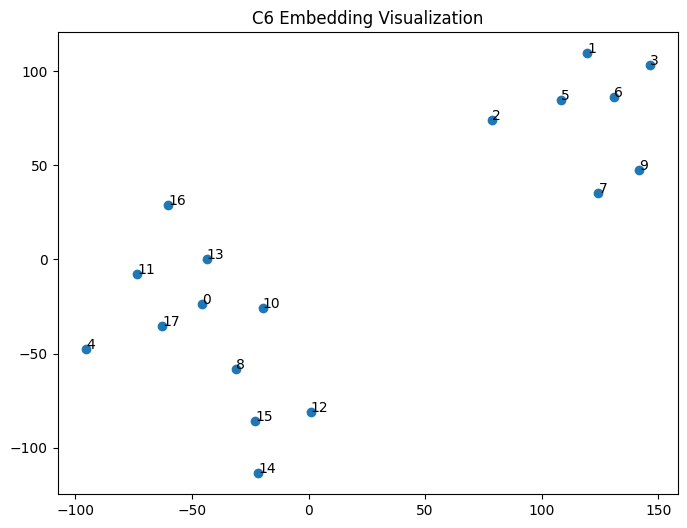

In [36]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import os
os.makedirs('results', exist_ok=True)
# LR embedding weight 뽑기
emb_weight = fm_model2.embeddings[5].weight.detach().cpu().numpy()
print(emb_weight.shape)  # (18, 16) 나와야 함

# t-SNE로 2차원 압축
tsne = TSNE(n_components=2, random_state=42, perplexity=5)

emb_2d = tsne.fit_transform(emb_weight)

plt.figure(figsize=(8, 6))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1])
for i in range(len(emb_2d)):
    plt.annotate(str(i), emb_2d[i])
plt.title('C6 Embedding Visualization')
plt.savefig('results/c6_embedding.png')
plt.show()

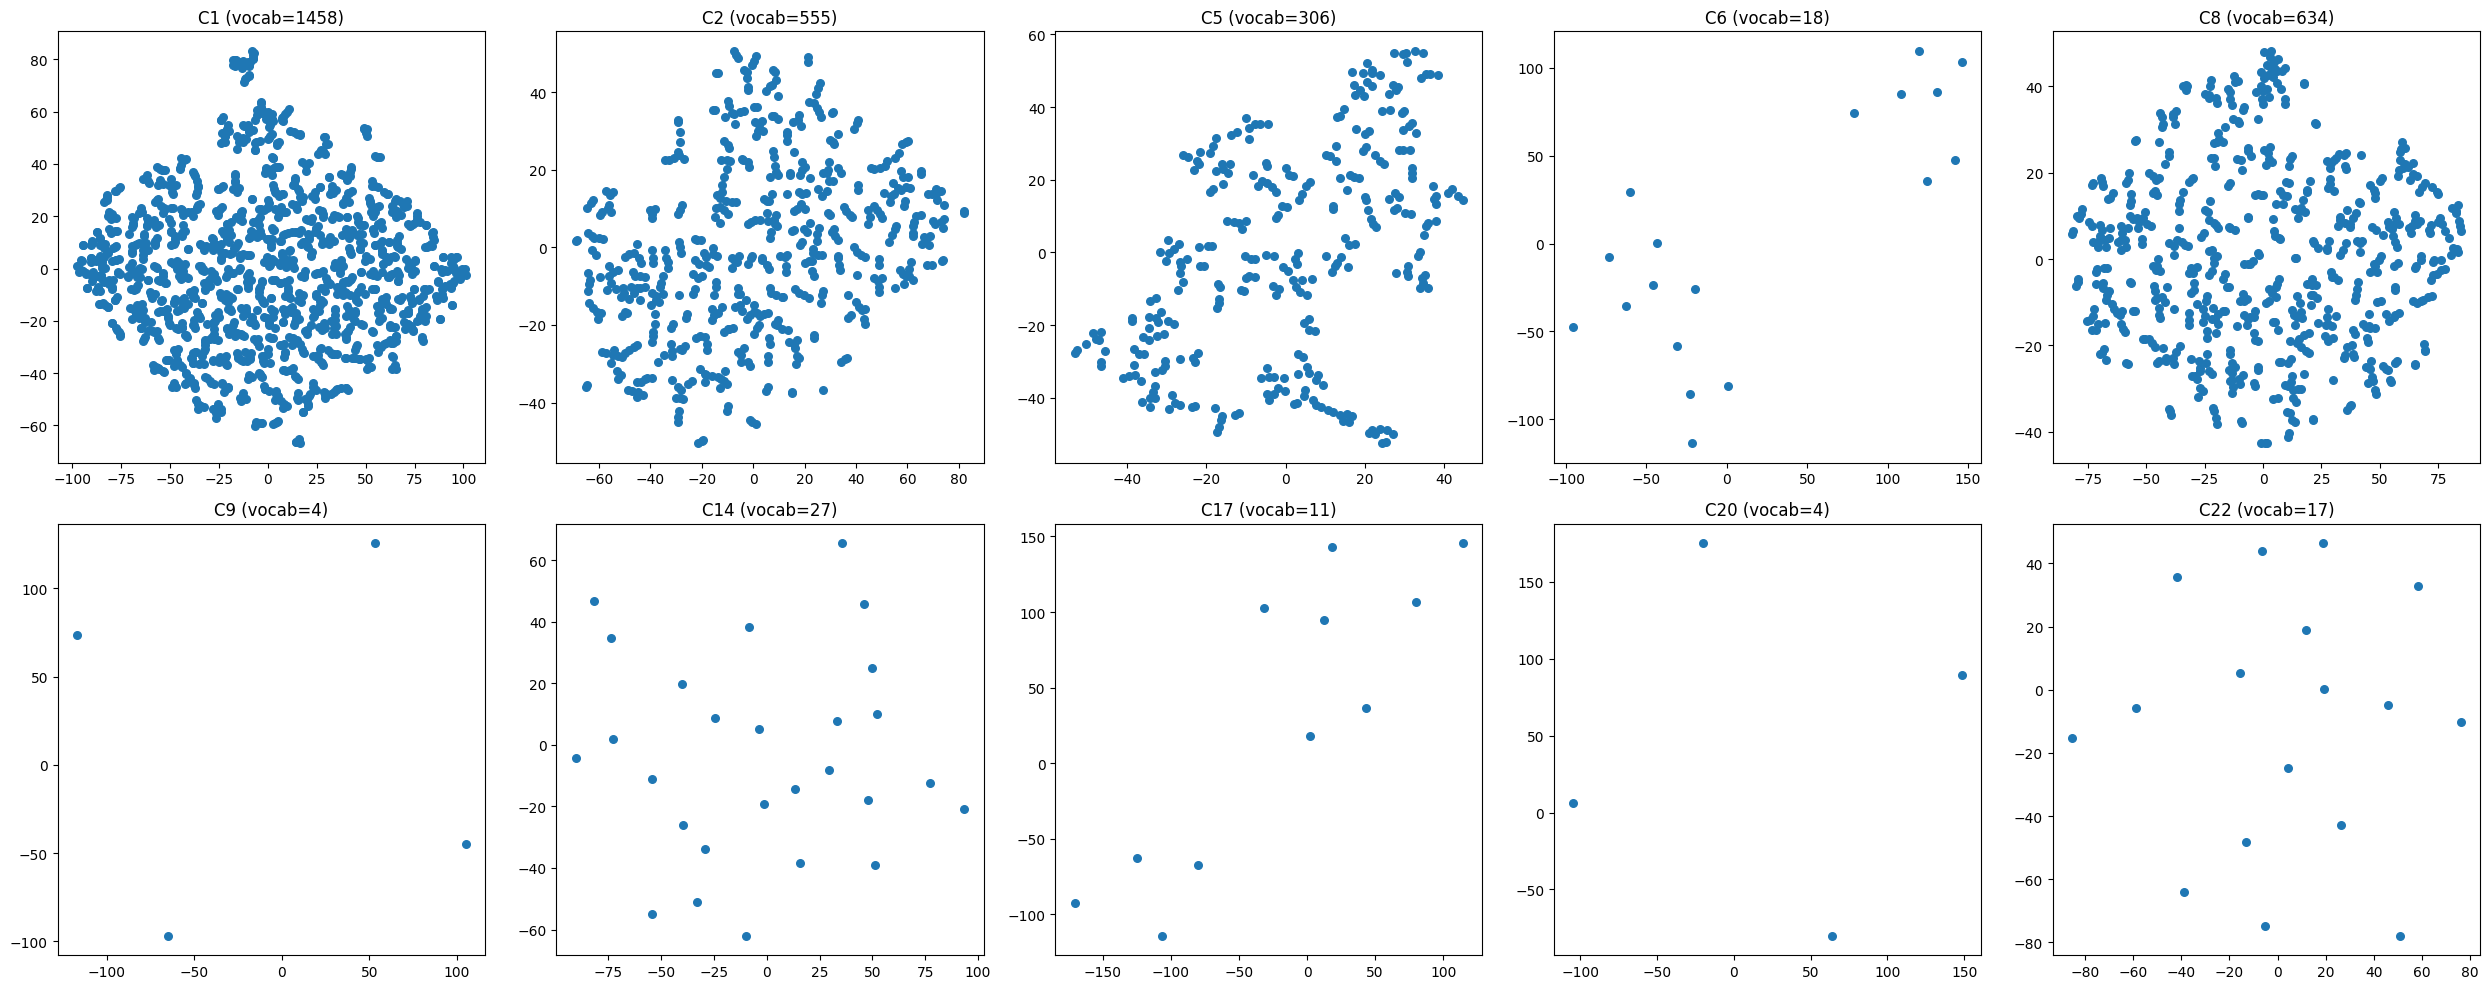

In [40]:
# vocab 작은 것들만
small_cats = [(i, col) for i, col in enumerate(CAT_COLS) 
              if len(vocab[col]) < 2000]

fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

for ax, (idx, col) in zip(axes, small_cats):
    emb_weight = fm_model2.embeddings[idx].weight.detach().cpu().numpy()
    n = len(emb_weight)
    perp = min(5, n - 1)
    
    tsne = TSNE(n_components=2, random_state=42, perplexity=perp)
    emb_2d = tsne.fit_transform(emb_weight)
    
    ax.scatter(emb_2d[:, 0], emb_2d[:, 1], s=30)
    ax.set_title(f'{col} (vocab={n})')

plt.tight_layout()
plt.savefig('results/small_embedding.png', dpi=150)
plt.show()

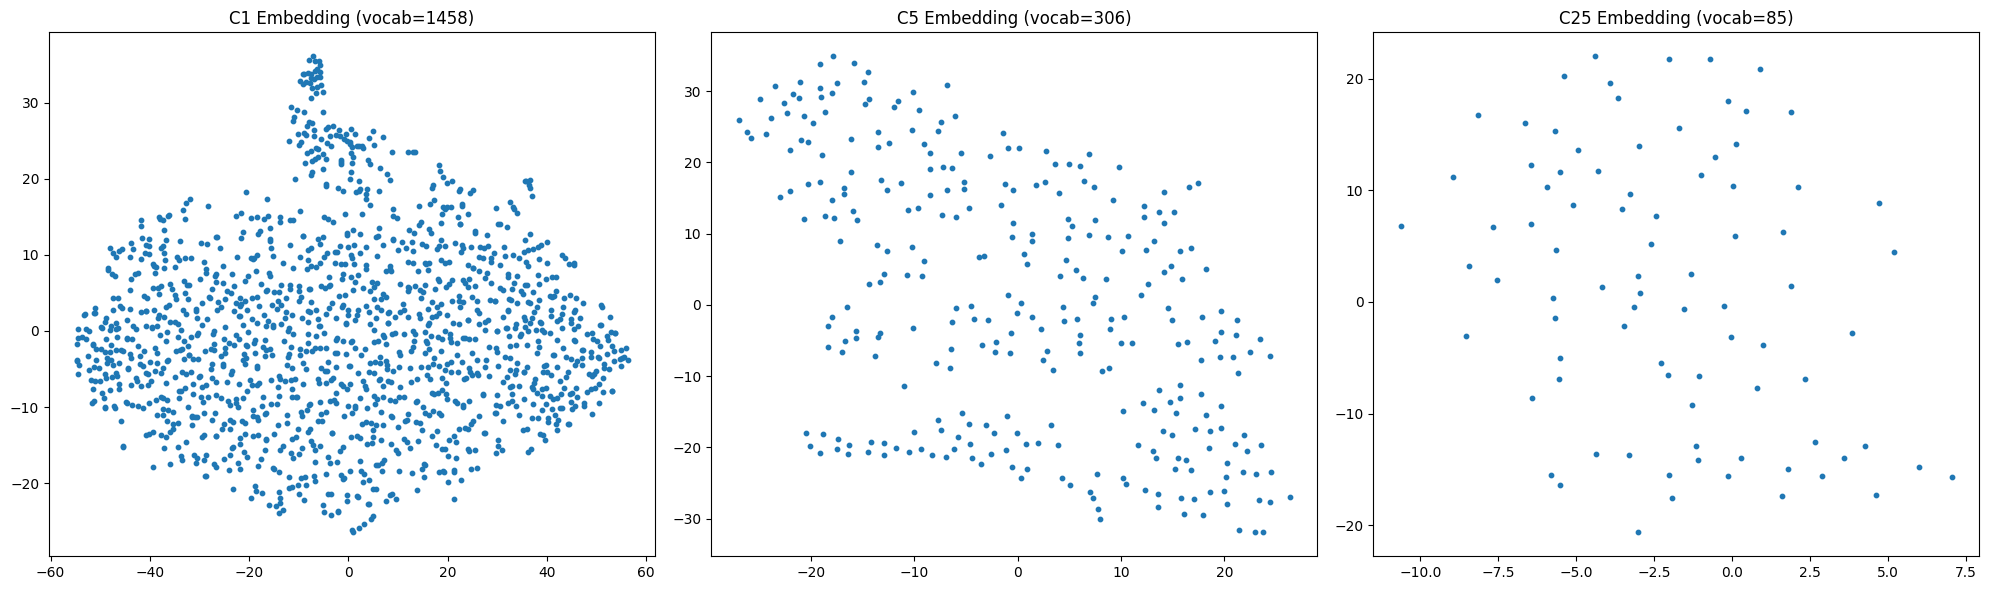

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

configs = [
    (0, 'C1', 1458, 30),
    (4, 'C5', 306, 15),
    (24, 'C25', 85, 10),
]

for ax, (idx, name, size, perp) in zip(axes, configs):
    emb_weight = fm_model2.embeddings[idx].weight.detach().cpu().numpy()
    tsne = TSNE(n_components=2, random_state=42, perplexity=perp)
    emb_2d = tsne.fit_transform(emb_weight)
    
    ax.scatter(emb_2d[:, 0], emb_2d[:, 1], s=10)
    ax.set_title(f'{name} Embedding (vocab={size})')

plt.tight_layout()
plt.savefig('results/embedding_visualization.png', dpi=150)
plt.show()

해당 컬럼: ['C1', 'C2', 'C5', 'C6', 'C8', 'C9', 'C14', 'C17', 'C20', 'C22', 'C23', 'C25']


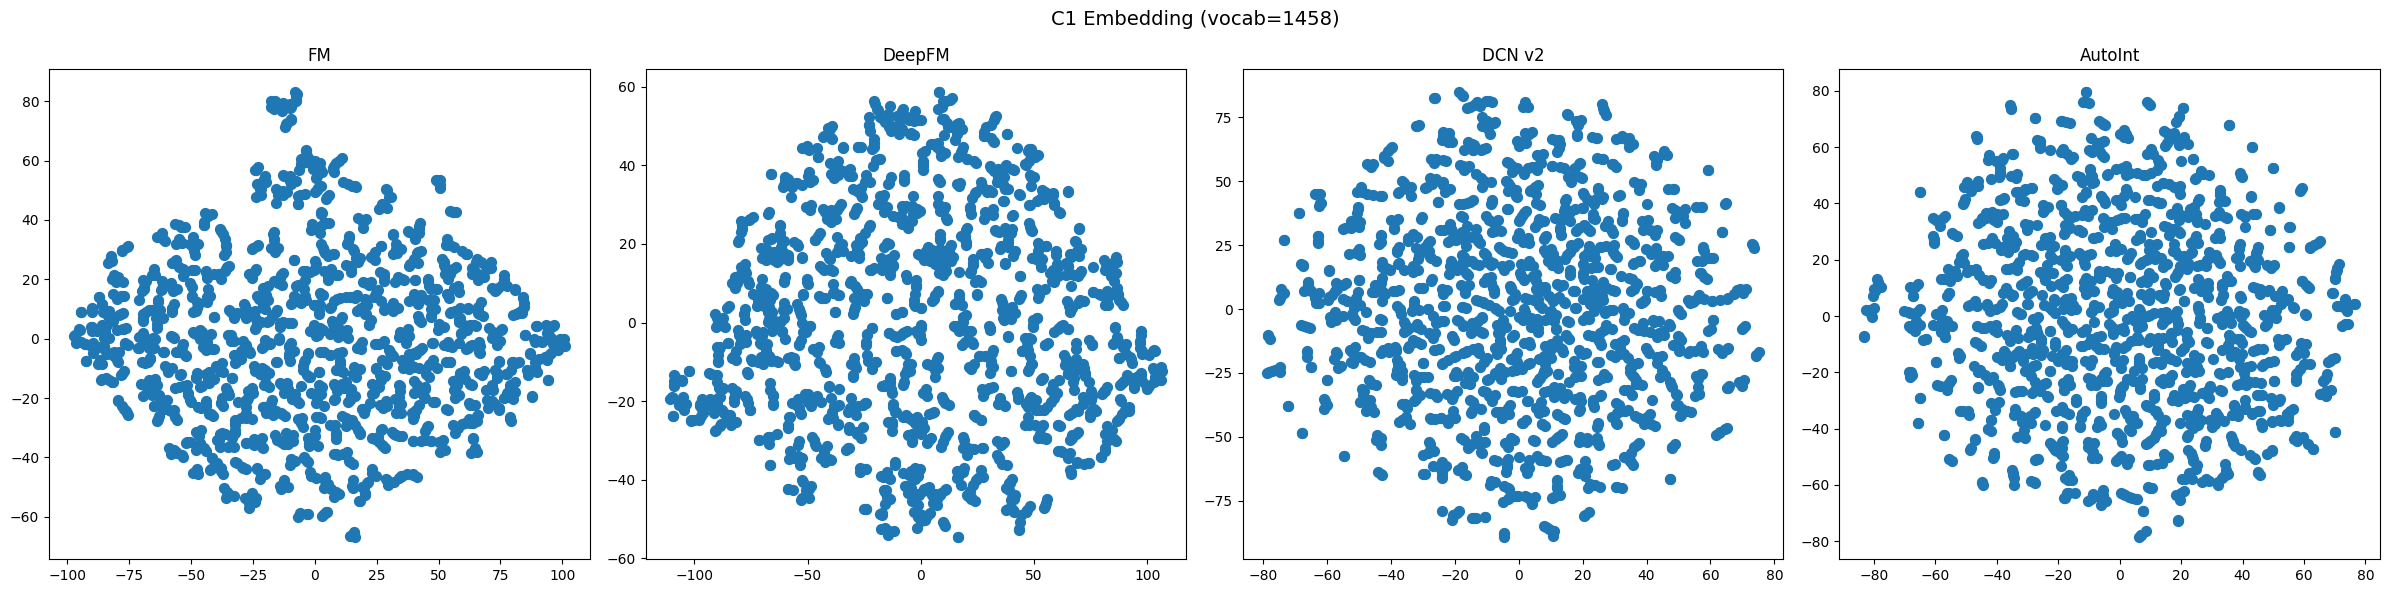

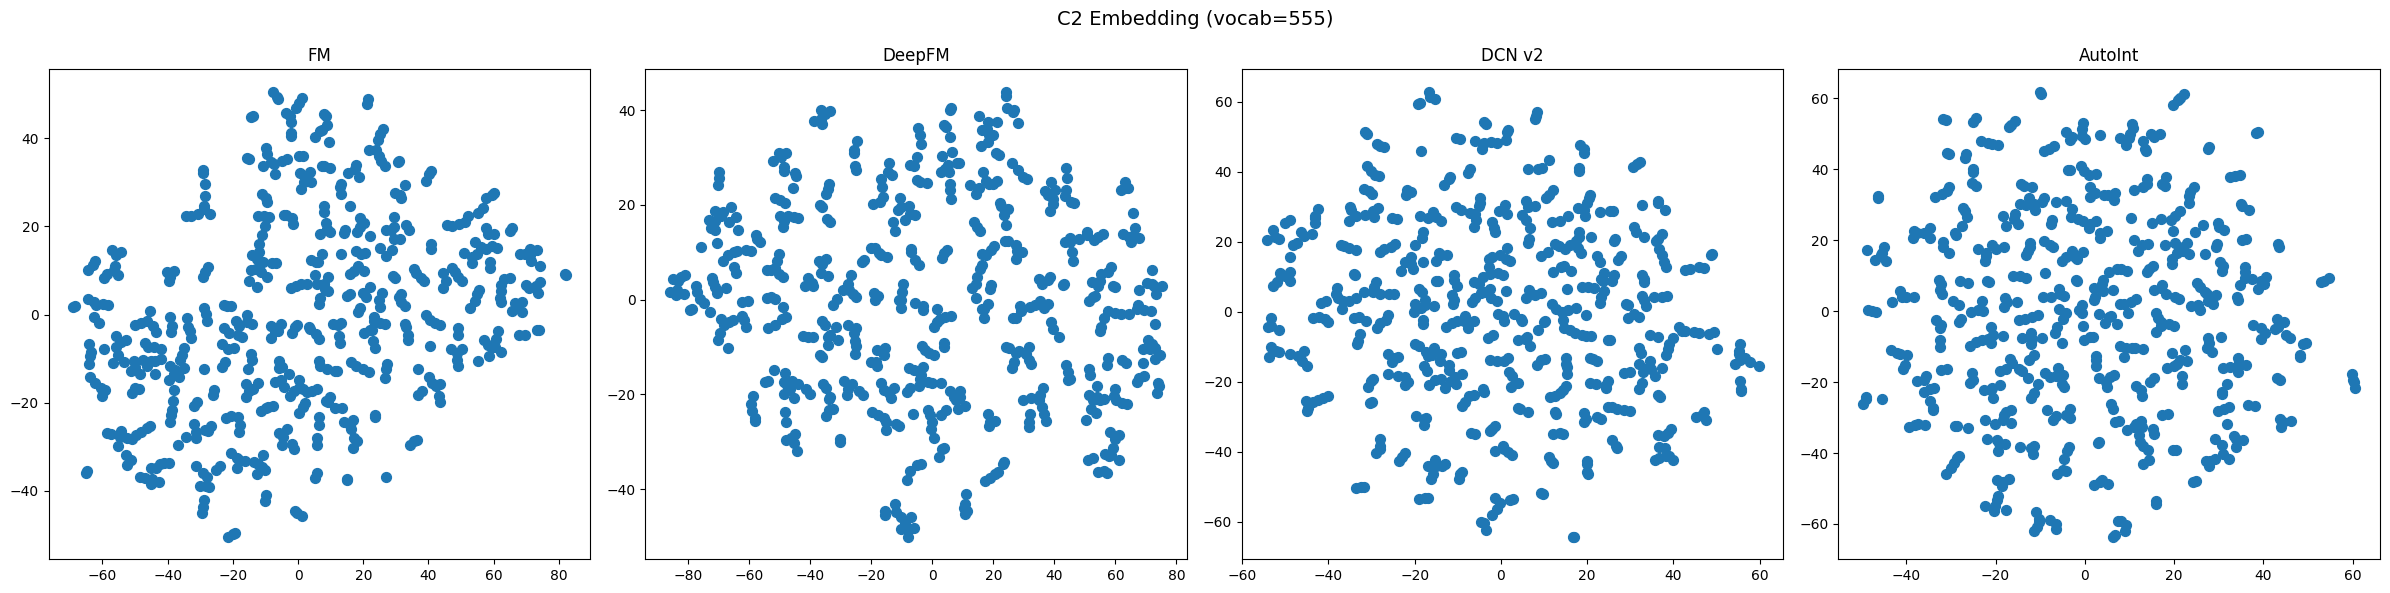

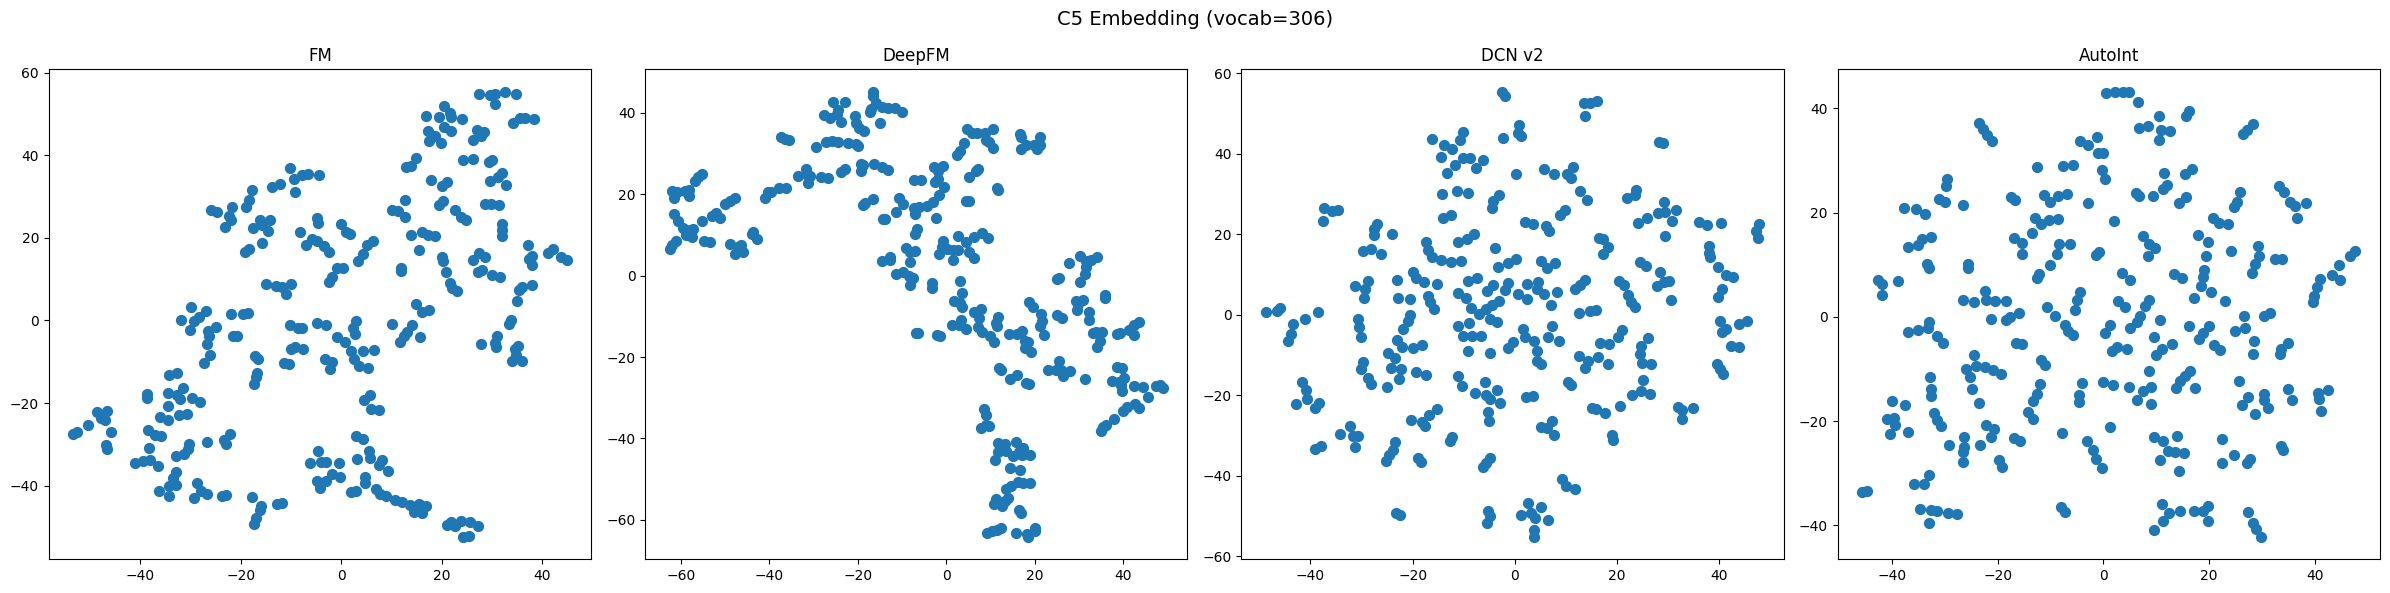

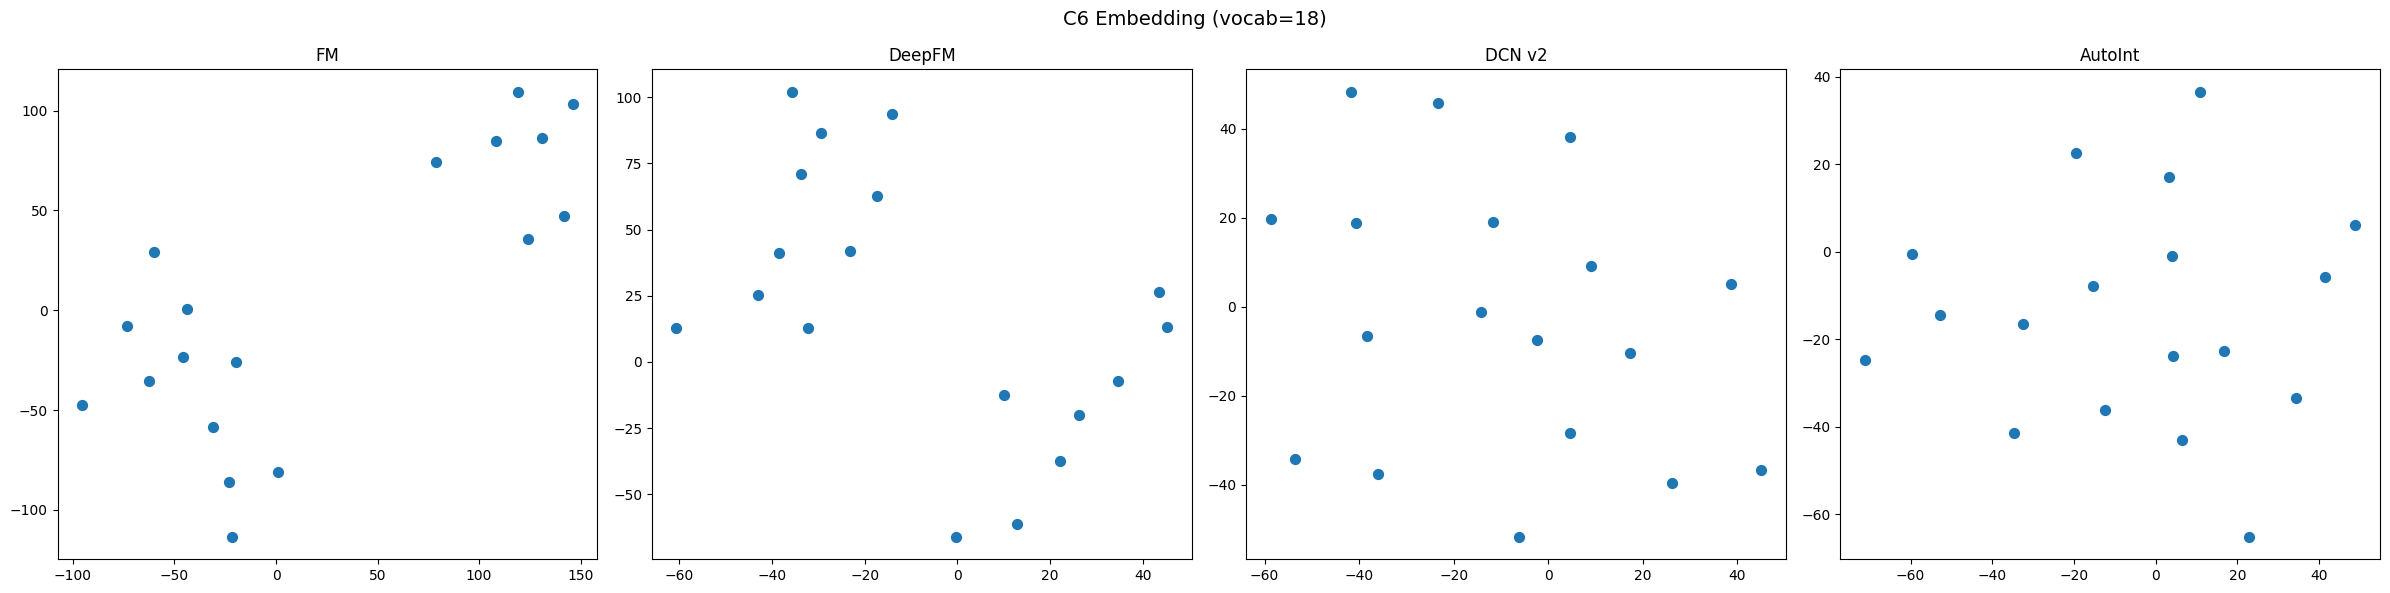

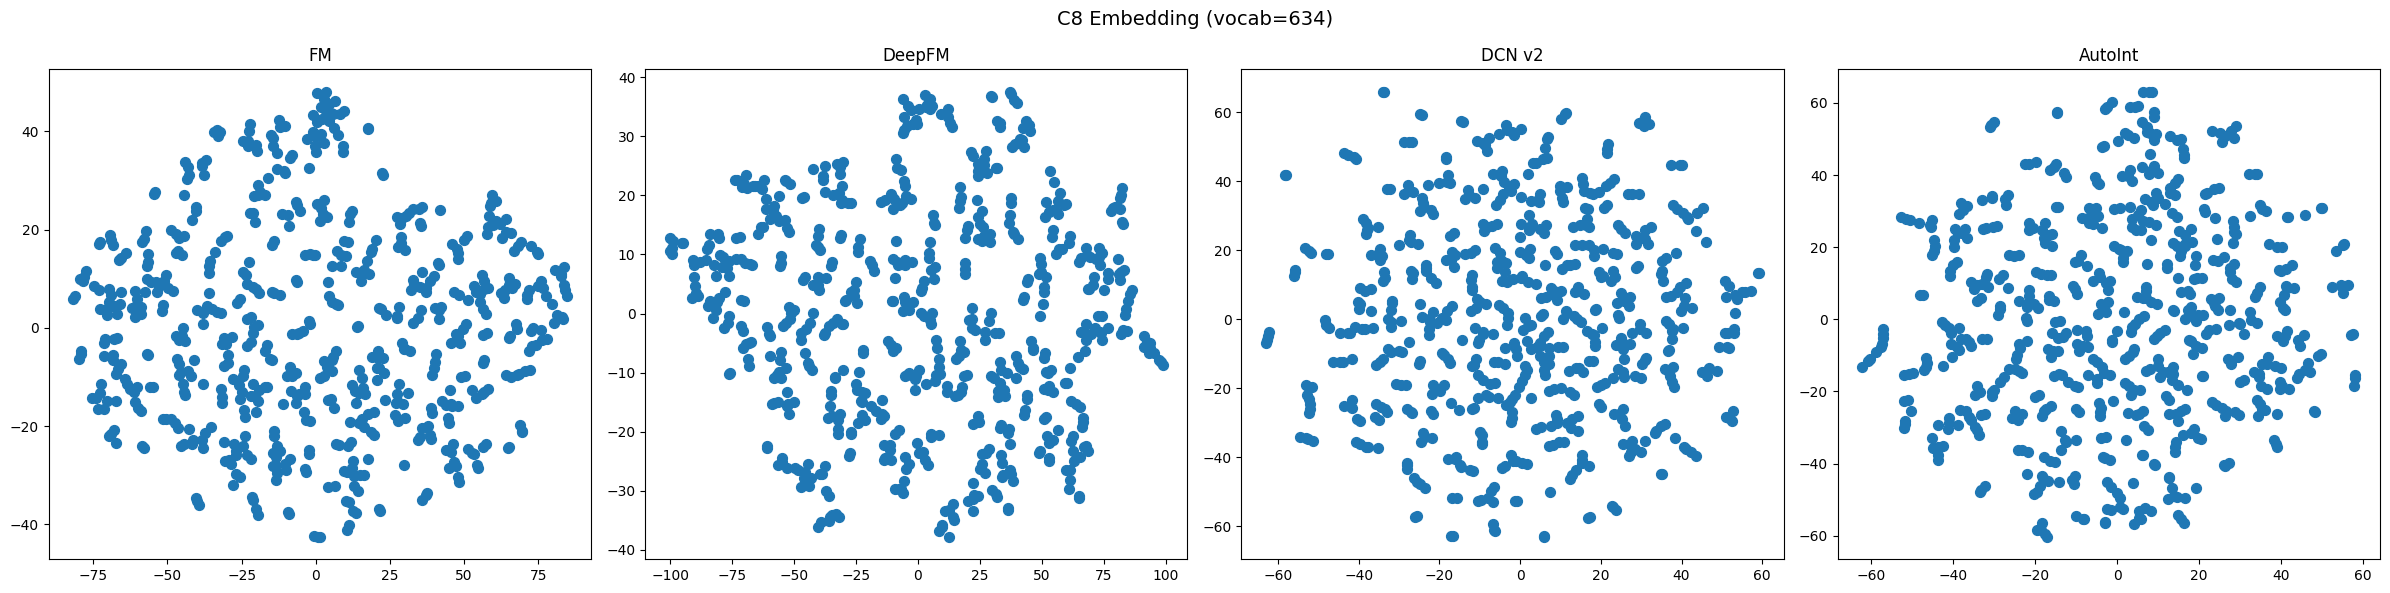

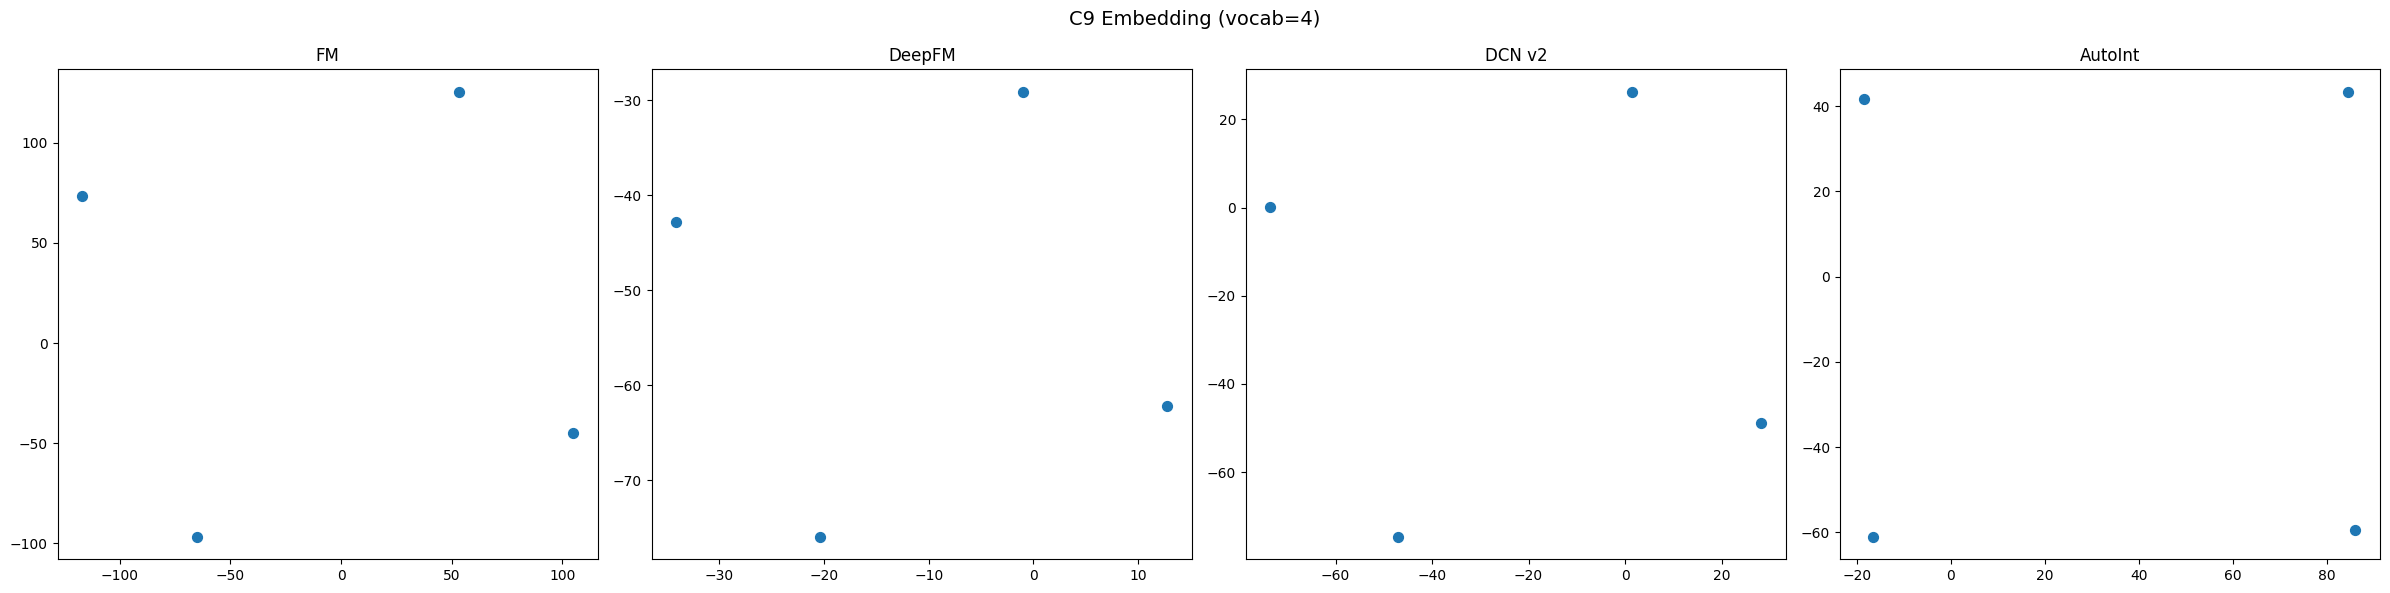

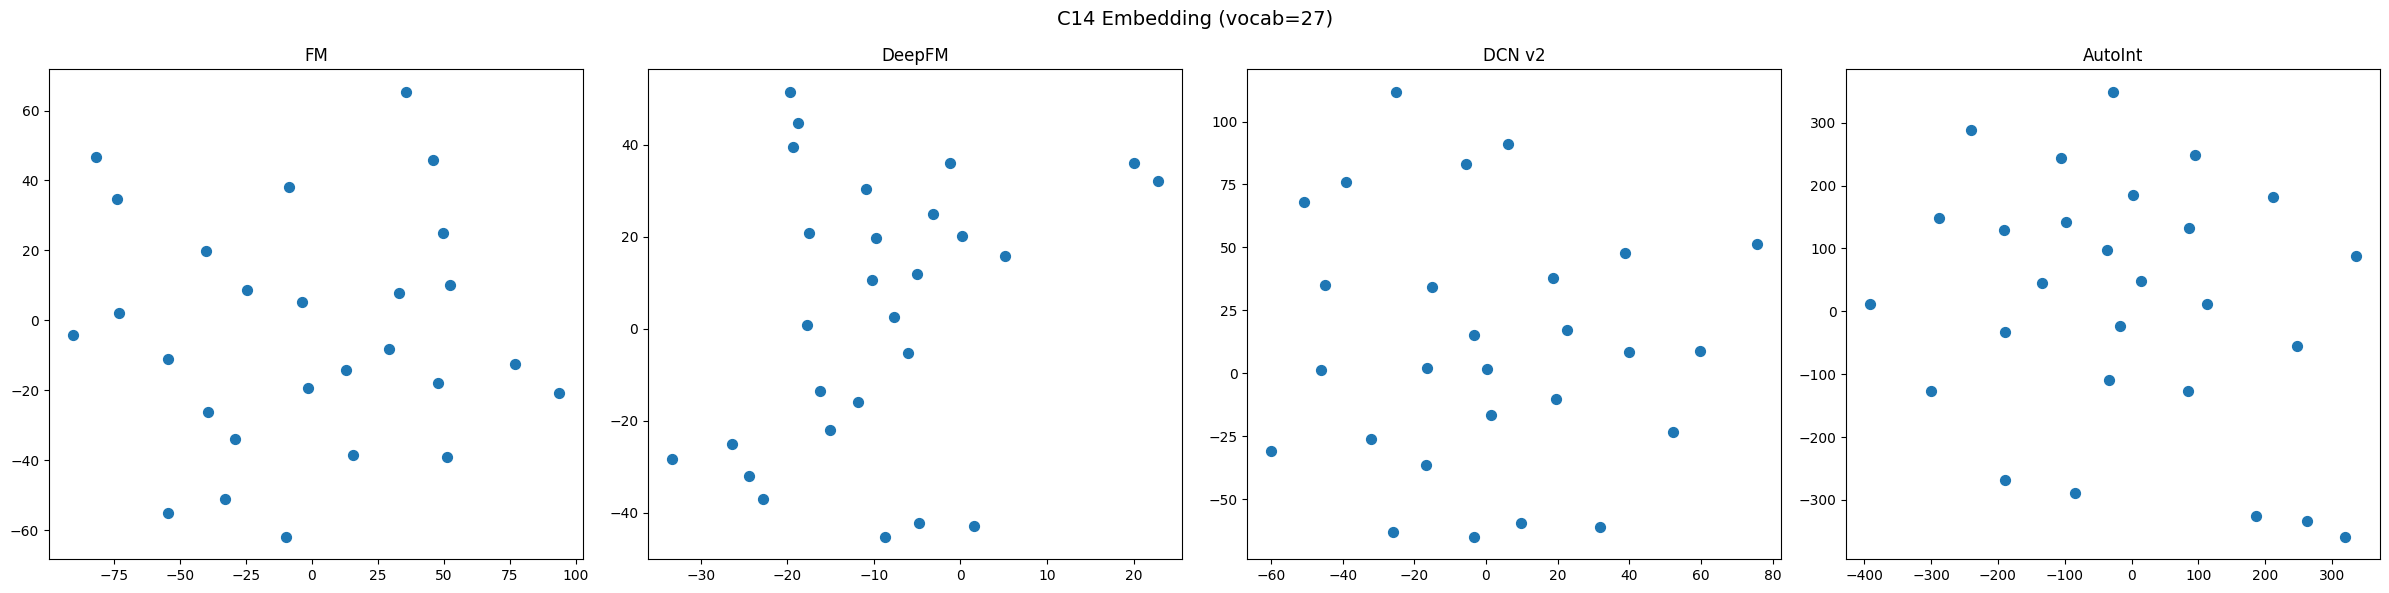

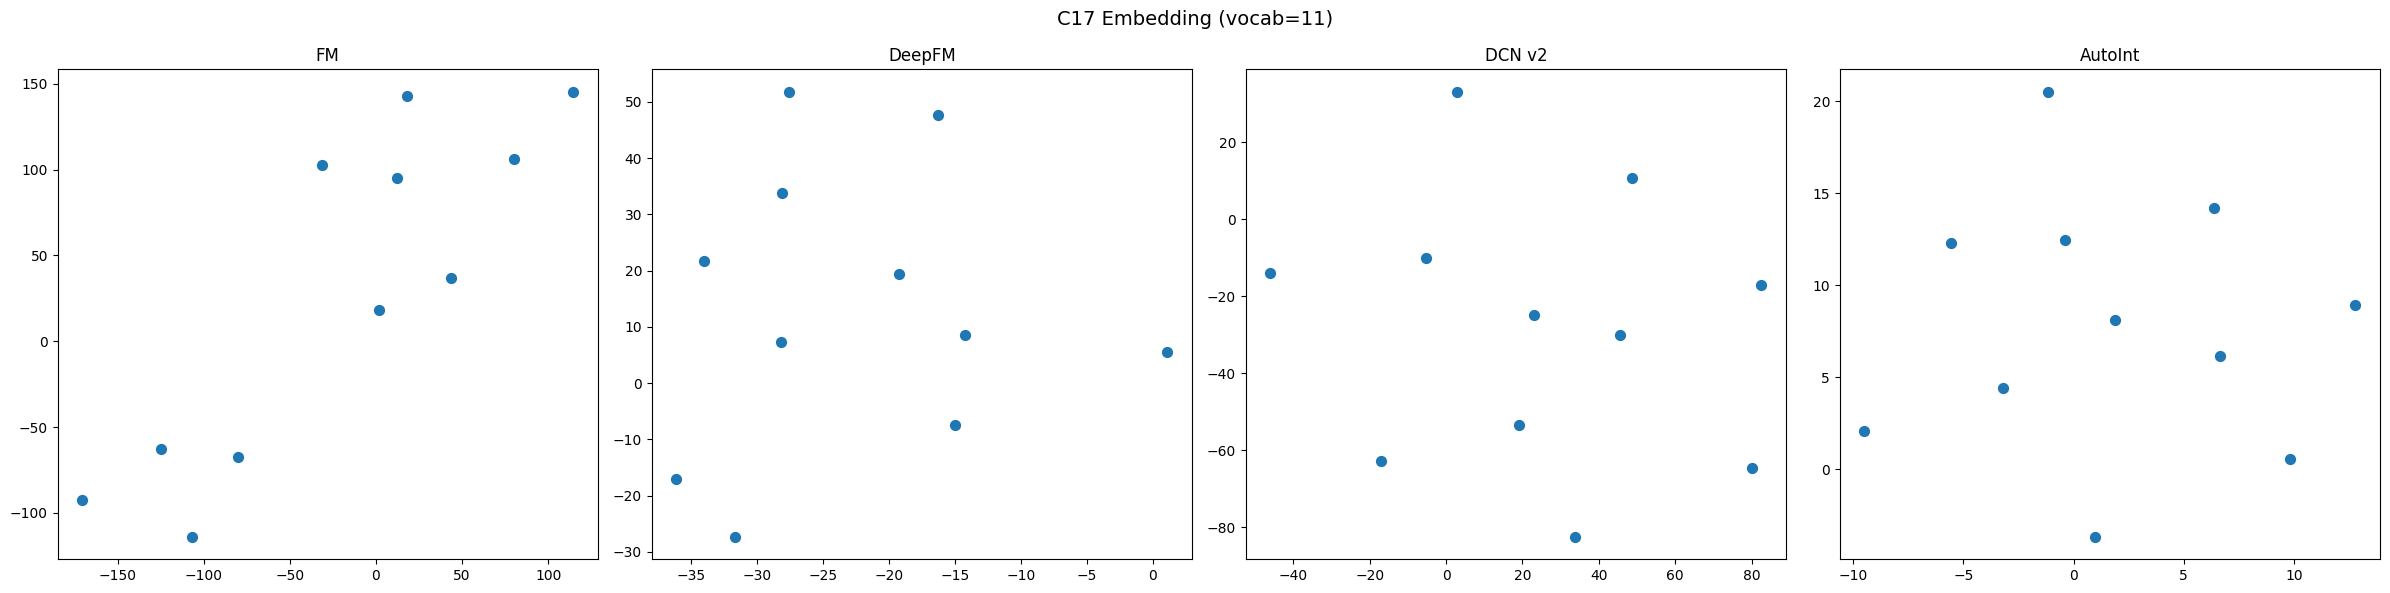

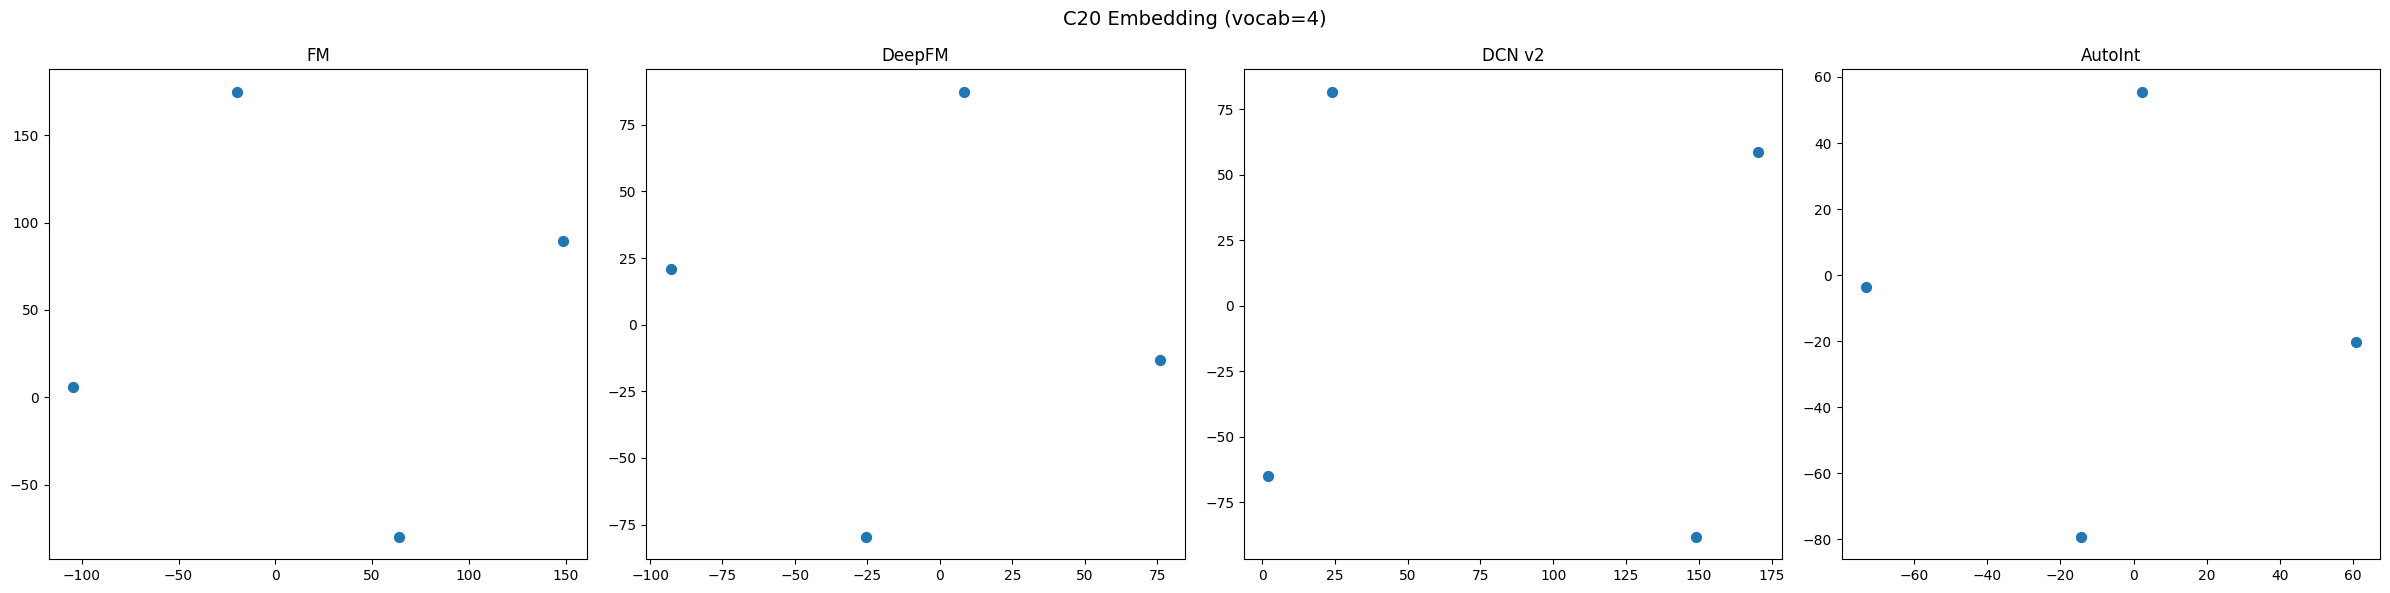

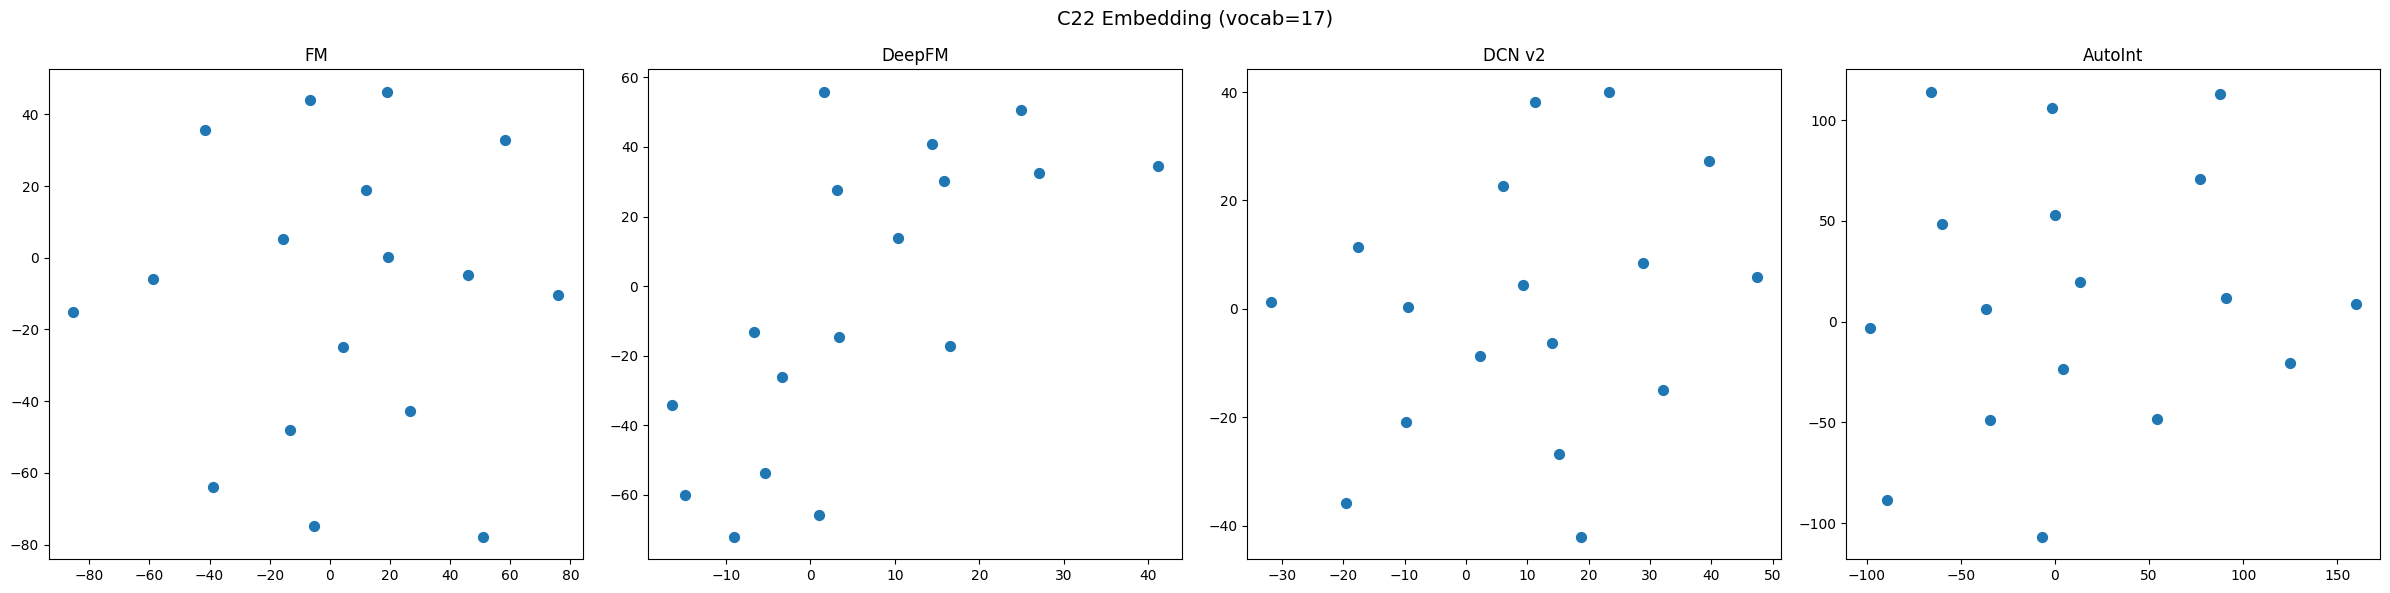

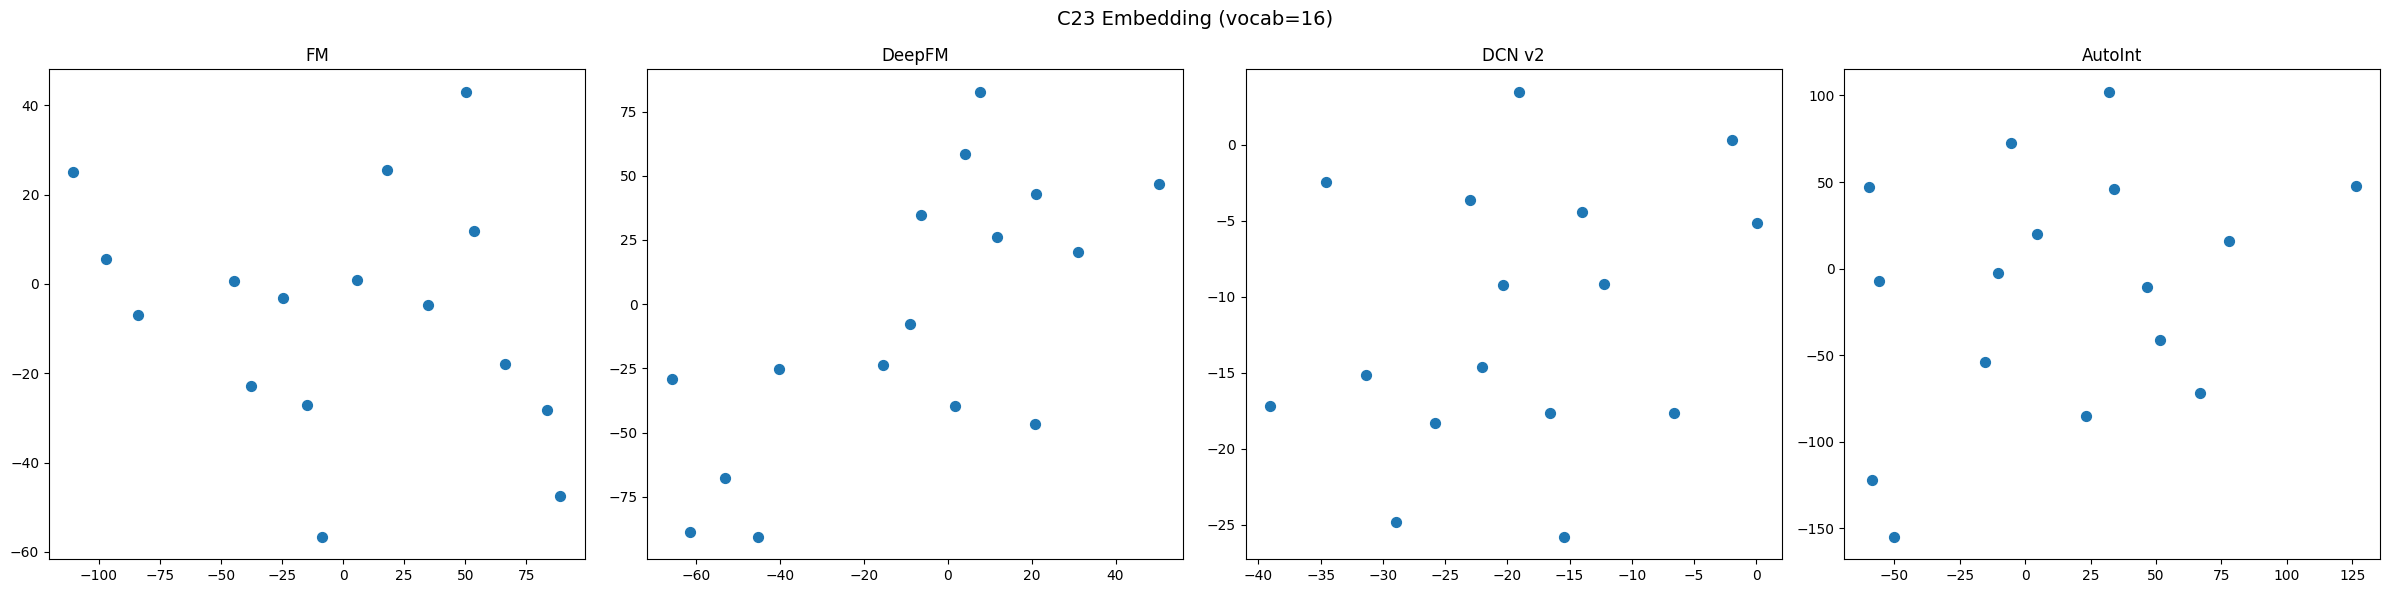

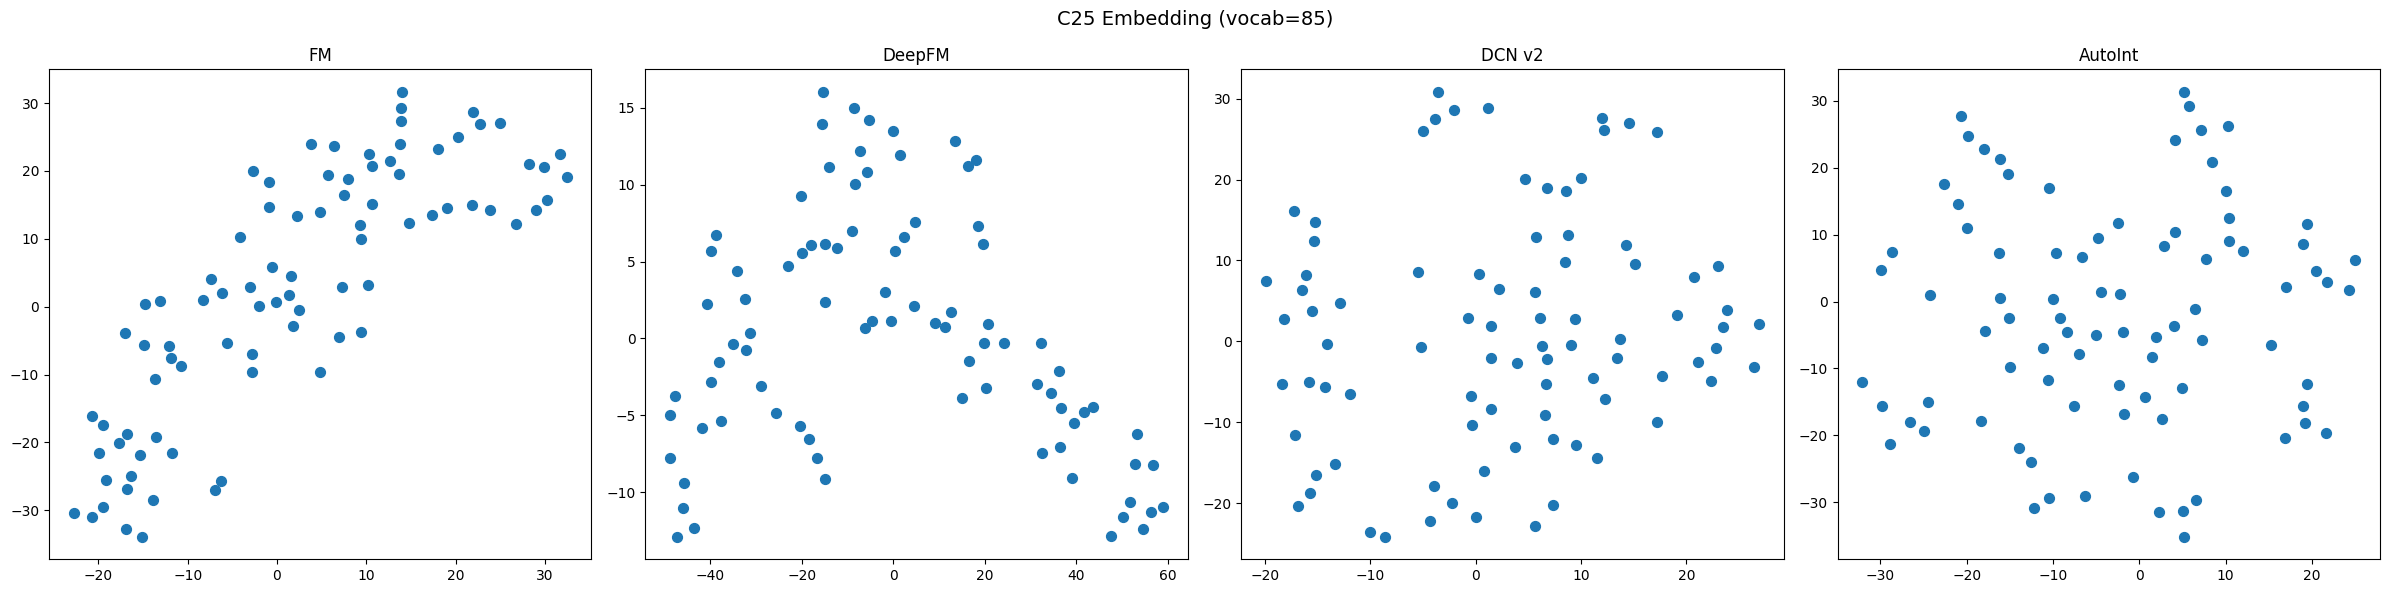

In [42]:
models = {
    'FM': fm_model2,
    'DeepFM': deepfm_model2,
    'DCN v2': dcn_model,
    'AutoInt': autoint_model,
}

small_cats = [(i, col) for i, col in enumerate(CAT_COLS) 
              if len(vocab[col]) < 2000]

print(f'해당 컬럼: {[col for _, col in small_cats]}')

for idx, col in small_cats:
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    fig.suptitle(f'{col} Embedding (vocab={len(vocab[col])})', fontsize=14)
    
    for ax, (name, m) in zip(axes, models.items()):
        emb_weight = m.embeddings[idx].weight.detach().cpu().numpy()
        n = len(emb_weight)
        perp = min(5, n - 1)
        
        tsne = TSNE(n_components=2, random_state=42, perplexity=perp)
        emb_2d = tsne.fit_transform(emb_weight)
        
        ax.scatter(emb_2d[:, 0], emb_2d[:, 1], s=50)
        ax.set_title(f'{name}')
    
    plt.tight_layout()
    plt.savefig(f'results/{col}_model_comparison.png', dpi=150)
    plt.show()

In [1]:
import pykrx
info = pykrx.get_market_sector_classifications("20240101", "005930")
print(info.columns.tolist())
print(info.iloc[-1])

ModuleNotFoundError: No module named 'pykrx'

In [ ]:
# 모델 저장
torch.save(model.state_dict(), 'results/lr_model.pt')

# 추론 속도 측정
import time
model.eval()
with torch.no_grad():
    batch = next(iter(val_loader))
    num = batch['num'].to(device)
    cat = batch['cat'].to(device)
    
    start = time.time()
    for _ in range(100):
        logit = model(num, cat)
    elapsed = (time.time() - start) / 100
    
    print(f'batch(4096) 추론 시간: {elapsed*1000:.2f}ms')
    print(f'단건 추론 시간: {elapsed/4096*1000:.4f}ms')